<a href="https://colab.research.google.com/github/huangste/macro-regime-classifier/blob/main/BBO_stage2_exploration_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import re
import pandas as pd
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel, WhiteKernel
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor

In [3]:
#!unzip /content/Initial_data_points_starter.zip

Archive:  /content/Initial_data_points_starter.zip
   creating: __MACOSX/
   creating: __MACOSX/initial_data/
  inflating: __MACOSX/initial_data/._function_7  
  inflating: __MACOSX/initial_data/._function_2  
  inflating: __MACOSX/initial_data/._function_6  
  inflating: __MACOSX/initial_data/._function_3  
  inflating: __MACOSX/initial_data/._function_4  
  inflating: __MACOSX/initial_data/._.DS_Store  
  inflating: __MACOSX/initial_data/._function_1  
  inflating: __MACOSX/initial_data/._function_5  
  inflating: __MACOSX/initial_data/._function_8  
  inflating: __MACOSX/._initial_data  
   creating: initial_data/
   creating: initial_data/function_1/
  inflating: initial_data/function_1/initial_outputs.npy  
  inflating: initial_data/function_1/initial_inputs.npy  
   creating: initial_data/function_5/
  inflating: initial_data/function_5/initial_outputs.npy  
  inflating: initial_data/function_5/initial_inputs.npy  
   creating: initial_data/function_6/
  inflating: initial_data/f

In [4]:
with open('/content/inputs.txt','r') as f:
    print(f.read())

[array([0.787844, 0.588977]), array([0.964226, 0.938835]), array([7.27499e-01, 2.27280e-02, 4.98000e-04]), array([0.472556, 0.398468, 0.362086, 0.382374]), array([0.361597, 0.442534, 0.999085, 0.996819]), array([0.505435, 0.279076, 0.635842, 0.932969, 0.005307]), array([0.028206, 0.649354, 0.724768, 0.163433, 0.35553 , 0.777568]), array([5.54650e-02, 2.79980e-02, 3.08203e-01, 1.99000e-04, 9.50318e-01, 5.98844e-01, 8.72710e-02, 3.01130e-01])]


In [5]:
import os


print(os.path.exists('/content/initial_data/function_1/initial_inputs.npy'))

True


In [6]:
with open('/content/inputs.txt','r') as f:
    print(f.read())

[array([0.787844, 0.588977]), array([0.964226, 0.938835]), array([7.27499e-01, 2.27280e-02, 4.98000e-04]), array([0.472556, 0.398468, 0.362086, 0.382374]), array([0.361597, 0.442534, 0.999085, 0.996819]), array([0.505435, 0.279076, 0.635842, 0.932969, 0.005307]), array([0.028206, 0.649354, 0.724768, 0.163433, 0.35553 , 0.777568]), array([5.54650e-02, 2.79980e-02, 3.08203e-01, 1.99000e-04, 9.50318e-01, 5.98844e-01, 8.72710e-02, 3.01130e-01])]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = '/content/initial_data'

# -----------------------------
# Loader
# -----------------------------
def load_function_data(i):

    X = np.load(f'{BASE_PATH}/function_{i}/initial_inputs.npy')
    Y = np.load(f'{BASE_PATH}/function_{i}/initial_outputs.npy')

    return X, Y

def load_new_round_data(
    input_path='/content/inputs.txt',
    output_path='/content/outputs.txt'
):
    new_X = {}
    new_Y = {}

    # ----- INPUTS -----
    with open(input_path, 'r') as f:
        txt_x = f.read()

    arrays = re.findall(r'array\(\[(.*?)\]\)', txt_x)

    for i, arr_str in enumerate(arrays, start=1):
        x = np.array([float(v.strip()) for v in arr_str.split(',')])
        new_X[i] = x

    # ----- OUTPUTS -----
    with open(output_path, 'r') as f:
        txt_y = f.read()

    # Extract values inside np.float64(...)
    y_values = re.findall(r'np\.float64\((.*?)\)', txt_y)

    for i, y_str in enumerate(y_values, start=1):
        new_Y[i] = float(y_str)

    return new_X, new_Y



def load_updated_function_data(i):
    X, Y = load_function_data(i)

    new_X, new_Y = load_new_round_data()

    X_updated = np.vstack([X, new_X[i].reshape(1, -1)])
    Y_updated = np.append(Y, new_Y[i])

    return X_updated, Y_updated



# -----------------------------
# Summary statistics
# -----------------------------
def summarize_function(i):

    X, Y = load_updated_function_data(i)

    print(f'\nFUNCTION {i}')
    print('-' * 40)

    print('Input shape :', X.shape)
    print('Output shape:', Y.shape)

    print('\nY statistics')
    print('Best Y :', np.max(Y))
    print('Mean Y :', np.mean(Y))
    print('Std Y  :', np.std(Y))
    print('Min Y  :', np.min(Y))

    best_idx = np.argmax(Y)

    print('\nBest observed X:')
    print(X[best_idx])



# -----------------------------
# Run summaries for all 8
# -----------------------------
for i in range(1, 9):

    summarize_function(i)


FUNCTION 1
----------------------------------------
Input shape : (11, 2)
Output shape: (11,)

Y statistics
Best Y : 7.710875114502849e-16
Mean Y : -0.00032782387676024593
Std Y  : 0.0010366701219489613
Min Y  : -0.0036060626443634764

Best observed X:
[0.73102363 0.73299988]

FUNCTION 2
----------------------------------------
Input shape : (11, 2)
Output shape: (11,)

Y statistics
Best Y : 0.6112052157614438
Mean Y : 0.20958561463110634
Std Y  : 0.224986809863866
Min Y  : -0.06562362443733738

Best observed X:
[0.70263656 0.9265642 ]

FUNCTION 3
----------------------------------------
Input shape : (16, 3)
Output shape: (16,)

Y statistics
Best Y : -0.034835313350078584
Mean Y : -0.11184310015153442
Std Y  : 0.08352687684503782
Min Y  : -0.3989255131463011

Best observed X:
[0.49258141 0.61159319 0.34017639]

FUNCTION 4
----------------------------------------
Input shape : (31, 4)
Output shape: (31,)

Y statistics
Best Y : -1.1360324509695903
Mean Y : -16.71915009643773
Std Y  : 7

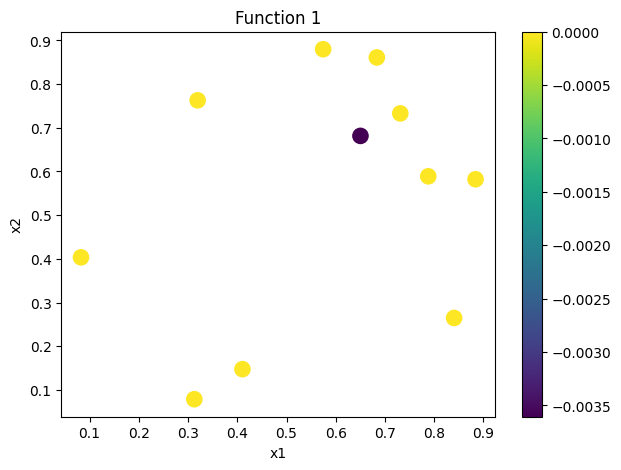

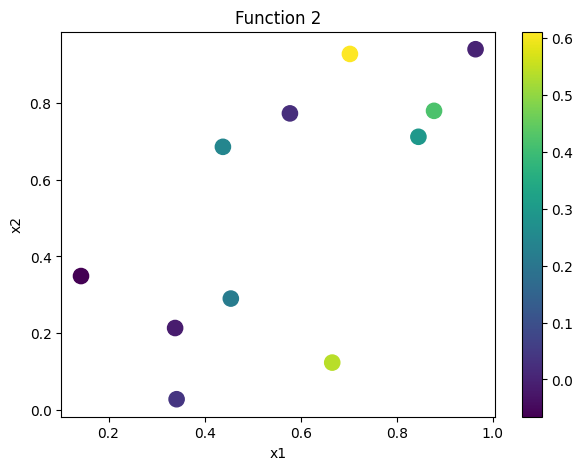

In [8]:
def plot_2d_function(i):

    X, Y = load_updated_function_data(i)

    plt.figure(figsize=(7,5))

    scatter = plt.scatter(
        X[:,0],
        X[:,1],
        c=Y,
        s=120
    )

    plt.colorbar(scatter)

    plt.xlabel('x1')
    plt.ylabel('x2')

    plt.title(f'Function {i}')

    plt.show()


plot_2d_function(1)
plot_2d_function(2)

In [9]:
kernel_rbf = ConstantKernel(1.0) * RBF(length_scale=0.3) + WhiteKernel(1e-6)

kernel_matern = ConstantKernel(1.0) * Matern(
    length_scale=0.3,
    nu=2.5
) + WhiteKernel(1e-6)

In [10]:
def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_best - xi) / sigma
    return (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)

def upper_confidence_bound(mu, sigma, beta=1.96):
    return mu + beta * sigma

def make_candidate_grid(d, n_candidates=50000, seed=42):
    rng = np.random.default_rng(seed)
    return rng.uniform(0.0, 0.999999, size=(n_candidates, d))

def propose_candidate(i, kernel_type='matern', acquisition='ei', seed=42):
    X, Y = load_updated_function_data(i)
    d = X.shape[1]

    if kernel_type == 'matern':
        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * Matern(length_scale=[0.3]*d, length_scale_bounds=(1e-2, 1e1), nu=2.5)
            + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-2))
        )
    elif kernel_type == 'rbf':
        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * RBF(length_scale=[0.3]*d, length_scale_bounds=(1e-2, 1e1))
            + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-2))
        )
    else:
        raise ValueError("kernel_type must be 'matern' or 'rbf'")

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=seed
    )

    gp.fit(X, Y)

    candidates = make_candidate_grid(d, n_candidates=50000, seed=seed + i)
    mu, sigma = gp.predict(candidates, return_std=True)

    if acquisition == 'ei':
        acq = expected_improvement(mu, sigma, np.max(Y), xi=0.01)
    elif acquisition == 'ucb':
        acq = upper_confidence_bound(mu, sigma, beta=1.96)
    else:
        raise ValueError("acquisition must be 'ei' or 'ucb'")

    best_idx = np.argmax(acq)
    x_next = candidates[best_idx]

    return {
        'function': i,
        'kernel': kernel_type,
        'acquisition': acquisition,
        'current_best_y': np.max(Y),
        'current_best_x': X[np.argmax(Y)],
        'candidate_x': x_next,
        'pred_mu': mu[best_idx],
        'pred_sigma': sigma[best_idx],
        'acq_value': acq[best_idx],
        'fitted_kernel': gp.kernel_
    }

results = []

for i in range(1, 9):
    for kernel_type in ['matern', 'rbf']:
        for acquisition in ['ei', 'ucb']:
            results.append(propose_candidate(i, kernel_type, acquisition, seed=42))

df_candidates = pd.DataFrame(results)

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.float_format', '{:.6f}'.format)
df_view = df_candidates[['function','kernel','acquisition','current_best_y','candidate_x','pred_mu','pred_sigma','acq_value']]
np.set_printoptions(precision=6, suppress=True)
display(df_view.round(6))

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

,function,kernel,acquisition,current_best_y,candidate_x,pred_mu,pred_sigma,acq_value
0,1,matern,ei,0.000000,"[0.9747537223171533, 0.9837598626757016]",-0.000324,0.001078,0.000000
1,1,matern,ucb,0.000000,"[0.5440363619805915, 0.3343554686862401]",-0.000261,0.001067,0.001831
2,1,rbf,ei,0.000000,"[0.1236991804229929, 0.4791418543060516]",-0.000317,0.001065,0.000000
3,1,rbf,ucb,0.000000,"[0.6995166083904734, 0.2066799606726361]",-0.000248,0.001049,0.001808
4,2,matern,ei,0.611205,"[0.6909797530164241, 0.02449379259859063]",0.611623,0.049284,0.015241
5,2,matern,ucb,0.611205,"[0.7402040449748385, 0.014032479812937303]",0.454175,0.153584,0.755200
6,2,rbf,ei,0.611205,"[0.6938551560367191, 0.004390825042260338]",0.614167,0.037781,0.011814
7,2,rbf,ucb,0.611205,"[0.7403991062033289, 0.013174425329851837]",0.447400,0.136305,0.714558
8,3,matern,ei,-0.034835,"[0.7418571611708729, 0.9926382423594186, 0.3976446661528739]",-0.046893,0.070187,0.018343
9,3,matern,ucb,-0.034835,"[0.8562645703410994, 0.9988784733363111, 0.4043898562636265]",-0.048551,0.071670,0.091922


In [11]:
from scipy.spatial.distance import euclidean

for i in range(1, 9):

    subset = df_candidates[df_candidates['function'] == i]

    x1 = subset.iloc[0]['candidate_x']
    x2 = subset.iloc[1]['candidate_x']
    x3 = subset.iloc[2]['candidate_x']
    x4 = subset.iloc[3]['candidate_x']



    print(f"\nFUNCTION {i}")

    print("Matern EI vs Matern UCB:",
          euclidean(x1, x2))

    print("RBF EI vs RBF UCB:",
          euclidean(x3, x4))

    print("Matern EI vs RBF EI:",
          euclidean(x1, x3))


FUNCTION 1
Matern EI vs Matern UCB: 0.779258308539675
RBF EI vs RBF UCB: 0.6370252693837123
Matern EI vs RBF EI: 0.989410515230979

FUNCTION 2
Matern EI vs Matern UCB: 0.050323652331746474
RBF EI vs RBF UCB: 0.0473655035983366
Matern EI vs RBF EI: 0.020307566252507705

FUNCTION 3
Matern EI vs Matern UCB: 0.11477583955397057
RBF EI vs RBF UCB: 0.23526106682025755
Matern EI vs RBF EI: 0.8211337607877629

FUNCTION 4
Matern EI vs Matern UCB: 0.03278562768983921
RBF EI vs RBF UCB: 0.10116495357613522
Matern EI vs RBF EI: 0.10116495357613522

FUNCTION 5
Matern EI vs Matern UCB: 0.39114876738918347
RBF EI vs RBF UCB: 0.0
Matern EI vs RBF EI: 0.5704100066546361

FUNCTION 6
Matern EI vs Matern UCB: 0.2441550883651823
RBF EI vs RBF UCB: 0.6034856985162299
Matern EI vs RBF EI: 0.32245838840336194

FUNCTION 7
Matern EI vs Matern UCB: 0.0
RBF EI vs RBF UCB: 0.0
Matern EI vs RBF EI: 0.0

FUNCTION 8
Matern EI vs Matern UCB: 0.2597385266323502
RBF EI vs RBF UCB: 0.0
Matern EI vs RBF EI: 0.54633862885

In [12]:
df_candidates.groupby("function")[["candidate_x", "pred_mu", "pred_sigma", "acq_value"]]

In [13]:
def select_first_round_candidates(df_candidates, distance_threshold=0.15):
    selected = []

    for i in range(1, 9):
        sub = df_candidates[df_candidates["function"] == i].copy()

        me = sub[(sub["kernel"] == "matern") & (sub["acquisition"] == "ei")].iloc[0]
        mu = sub[(sub["kernel"] == "matern") & (sub["acquisition"] == "ucb")].iloc[0]
        re = sub[(sub["kernel"] == "rbf") & (sub["acquisition"] == "ei")].iloc[0]
        ru = sub[(sub["kernel"] == "rbf") & (sub["acquisition"] == "ucb")].iloc[0]

        x_me = me["candidate_x"]
        x_mu = mu["candidate_x"]
        x_re = re["candidate_x"]
        x_ru = ru["candidate_x"]

        d_matern = np.linalg.norm(x_me - x_mu)
        d_rbf = np.linalg.norm(x_re - x_ru)
        d_ei = np.linalg.norm(x_me - x_re)

        # Default choice
        chosen = me.copy()
        reason = "Defaulted to Matérn + EI as balanced first-round BO choice."

        # High consensus
        if max(d_matern, d_rbf, d_ei) < distance_threshold:
            reason = "High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate."

        # Strong kernel disagreement
        elif d_ei > 0.5:
            # choose higher uncertainty among Matern EI and Matern UCB
            if mu["pred_sigma"] > me["pred_sigma"]:
                chosen = mu.copy()
                reason = "Large kernel disagreement; selected Matérn + UCB to prioritise exploration."
            else:
                reason = "Large kernel disagreement; retained Matérn + EI but flagged model sensitivity."

        # EI/UCB disagreement inside Matérn
        elif d_matern > 0.5:
            chosen = mu.copy()
            reason = "Large EI/UCB disagreement under Matérn; selected UCB for more exploration."

        selected.append({
            "function": i,
            "chosen_kernel": chosen["kernel"],
            "chosen_acquisition": chosen["acquisition"],
            "candidate_x": chosen["candidate_x"],
            "current_best_y": chosen["current_best_y"],
            "pred_mu": chosen["pred_mu"],
            "pred_sigma": chosen["pred_sigma"],
            "reason": reason,
            "d_matern_EI_UCB": d_matern,
            "d_rbf_EI_UCB": d_rbf,
            "d_maternEI_rbfEI": d_ei
        })

    return pd.DataFrame(selected)

df_selected = select_first_round_candidates(df_candidates)
df_selected

,function,chosen_kernel,chosen_acquisition,candidate_x,current_best_y,pred_mu,pred_sigma,reason,d_matern_EI_UCB,d_rbf_EI_UCB,d_maternEI_rbfEI
0,1,matern,ei,"[0.9747537223171533, 0.9837598626757016]",0.000000,-0.000324,0.001078,Large kernel disagreement; retained Matérn + EI but flagged model sensitivity.,0.779258,0.637025,0.989411
1,2,matern,ei,"[0.6909797530164241, 0.02449379259859063]",0.611205,0.611623,0.049284,High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate.,0.050324,0.047366,0.020308
2,3,matern,ucb,"[0.8562645703410994, 0.9988784733363111, 0.4043898562636265]",-0.034835,-0.048551,0.071670,Large kernel disagreement; selected Matérn + UCB to prioritise exploration.,0.114776,0.235261,0.821134
3,4,matern,ei,"[0.3787620181000855, 0.41628639584994087, 0.4015462457802032, 0.3967990143265799]",-1.136032,-1.169315,0.351744,High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate.,0.032786,0.101165,0.101165
4,5,matern,ucb,"[0.9865902910635881, 0.8660870186966376, 0.9788097484753656, 0.997372407185474]",1712.518505,1660.472845,66.120655,Large kernel disagreement; selected Matérn + UCB to prioritise exploration.,0.391149,0.000000,0.570410
5,6,matern,ei,"[0.3853922457936367, 0.004581053843062508, 0.6394966407903336, 0.9796148340143155, 0.07782398857875884]",-0.404747,-0.492641,0.227430,Defaulted to Matérn + EI as balanced first-round BO choice.,0.244155,0.603486,0.322458
6,7,matern,ei,"[0.042483134979061934, 0.3348698119888431, 0.6527417325032805, 0.13207005291971977, 0.3974087784063957, 0.7361862937940189]",1.364968,1.335312,0.093599,High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate.,0.000000,0.000000,0.000000
7,8,matern,ucb,"[0.08921510616402802, 0.11797896618347681, 0.011348719910334733, 0.20337673503165754, 0.9526883467846847, 0.11302559318731534, 0.27496411108530083, 0.6761787251635358]",9.808024,9.947747,0.189469,Large kernel disagreement; selected Matérn + UCB to prioritise exploration.,0.259739,0.000000,0.546339


In [15]:
def format_submission(x):
    return "-".join([f"{v:.6f}" for v in x])

df_selected["submission_string"] = df_selected["candidate_x"].apply(format_submission)

df_selected[["function", "submission_string", "reason"]]

,function,submission_string,reason
0,1,0.974754-0.983760,Large kernel disagreement; retained Matérn + EI but flagged model sensitivity.
1,2,0.690980-0.024494,High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate.
2,3,0.856265-0.998878-0.404390,Large kernel disagreement; selected Matérn + UCB to prioritise exploration.
3,4,0.378762-0.416286-0.401546-0.396799,High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate.
4,5,0.986590-0.866087-0.978810-0.997372,Large kernel disagreement; selected Matérn + UCB to prioritise exploration.
5,6,0.385392-0.004581-0.639497-0.979615-0.077824,Defaulted to Matérn + EI as balanced first-round BO choice.
6,7,0.042483-0.334870-0.652742-0.132070-0.397409-0.736186,High agreement across kernels/acquisitions; selected Matérn + EI as consensus candidate.
7,8,0.089215-0.117979-0.011349-0.203377-0.952688-0.113026-0.274964-0.676179,Large kernel disagreement; selected Matérn + UCB to prioritise exploration.


In [16]:
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
import numpy as np
import pandas as pd

def propose_tree_candidate(i, model_type="extra_trees", seed=42, n_candidates=50000):
    X, Y = load_updated_function_data(i)
    d = X.shape[1]

    if model_type == "extra_trees":
        model = ExtraTreesRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            random_state=seed,
            bootstrap=False
        )
    elif model_type == "random_forest":
        model = RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            random_state=seed,
            bootstrap=True
        )
    else:
        raise ValueError("model_type must be 'extra_trees' or 'random_forest'")

    model.fit(X, Y)

    candidates = make_candidate_grid(d, n_candidates=n_candidates, seed=seed + 100 + i)

    # Prediction from each tree
    tree_preds = np.array([tree.predict(candidates) for tree in model.estimators_])

    mu = tree_preds.mean(axis=0)
    sigma = tree_preds.std(axis=0)

    # UCB-style tree acquisition
    beta = 1.96
    acq = mu + beta * sigma

    best_idx = np.argmax(acq)

    return {
        "function": i,
        "model": model_type,
        "current_best_y": np.max(Y),
        "current_best_x": X[np.argmax(Y)],
        "candidate_x": candidates[best_idx],
        "pred_mu": mu[best_idx],
        "pred_sigma": sigma[best_idx],
        "acq_value": acq[best_idx]
    }


tree_results = []

for i in [1, 3, 5, 8]:
    for model_type in ["extra_trees", "random_forest"]:
        tree_results.append(
            propose_tree_candidate(i, model_type=model_type, seed=42)
        )

df_tree = pd.DataFrame(tree_results)

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", "{:.6f}".format)

df_tree[["function", "model", "current_best_y", "candidate_x", "pred_mu", "pred_sigma", "acq_value"]]

,function,model,current_best_y,candidate_x,pred_mu,pred_sigma,acq_value
0,1,extra_trees,0.000000,"[0.7031806923425181, 0.7144173561755475]",-0.000981,0.001605,0.002164
1,1,random_forest,0.000000,"[0.6366516800652781, 0.18753667721998896]",-0.000988,0.001608,0.002164
2,3,extra_trees,-0.034835,"[0.14182750823860235, 0.44366570295589397, 0.47197761845169234]",-0.105472,0.117964,0.125738
3,3,random_forest,-0.034835,"[0.4858402103031438, 0.7288034048900716, 0.9433171705264989]",-0.159000,0.141300,0.117948
4,5,extra_trees,1712.518505,"[0.7302334079557435, 0.2346162571775947, 0.9944769170698858, 0.999806035358575]",1353.145218,653.585347,2634.172498
5,5,random_forest,1712.518505,"[0.7132202711788537, 0.4115053464716257, 0.95215656811862, 0.988021963250493]",1325.076940,557.719019,2418.206217
6,8,extra_trees,9.808024,"[0.06261611590180943, 0.7455976557625414, 0.2476624542724389, 0.8793544886445175, 0.9127164702795169, 0.8943795799374089, 0.12258499797644055, 0.420257520533716]",9.291245,0.679994,10.624034
7,8,random_forest,9.808024,"[0.09049569918330154, 0.07080461617960644, 0.5602516331390964, 0.26961574471616206, 0.898994315479984, 0.9767809088627034, 0.45933824733540857, 0.051571421933184675]",8.291412,1.275411,10.791217


In [20]:
def compare_tree_vs_gp(df_selected, df_tree):

    rows = []

    for _, row in df_tree.iterrows():

        f = row["function"]

        gp_row = df_selected[df_selected["function"] == f].iloc[0]

        gp_x = gp_row["candidate_x"]
        tree_x = row["candidate_x"]

        dist = np.linalg.norm(gp_x - tree_x)

        rows.append({

            "function": f,
            "tree_model": row["model"],

            "gp_best_y": gp_row["current_best_y"],

            "gp_pred_mu": gp_row["pred_mu"],
            "tree_pred_mu": row["pred_mu"],

            "gp_pred_sigma": gp_row["pred_sigma"],
            "tree_pred_sigma": row["pred_sigma"],

            "distance_vs_gp": dist,

            "gp_selected_x": gp_x,
            "tree_candidate_x": tree_x
        })

    return pd.DataFrame(rows)

df_tree_compare = compare_tree_vs_gp(df_selected, df_tree)

df_tree_compare[
    [
        "function",
        "tree_model",
        "gp_best_y",
        "gp_pred_mu",
        "tree_pred_mu",
        "gp_pred_sigma",
        "tree_pred_sigma",
        "distance_vs_gp"
    ]
]


,function,tree_model,gp_best_y,gp_pred_mu,tree_pred_mu,gp_pred_sigma,tree_pred_sigma,distance_vs_gp
0,1,extra_trees,0.000000,-0.000324,-0.000981,0.001078,0.001605,0.382488
1,1,random_forest,0.000000,-0.000324,-0.000988,0.001078,0.001608,0.865034
2,3,extra_trees,-0.034835,-0.048551,-0.105472,0.071670,0.117964,0.907331
3,3,random_forest,-0.034835,-0.048551,-0.159000,0.071670,0.141300,0.707529
4,5,extra_trees,1712.518505,1660.472845,1353.145218,66.120655,653.585347,0.681708
5,5,random_forest,1712.518505,1660.472845,1325.076940,66.120655,557.719019,0.531200
6,8,extra_trees,9.808024,9.947747,9.291245,0.189469,0.679994,1.268160
7,8,random_forest,9.808024,9.947747,8.291412,0.189469,1.275411,1.216961
